In [1]:
import numpy as np
import pandas as pd

IMPORTING DATA

In [2]:
df=pd.read_csv("Electronics_rating.csv",header=None)
df.head()

,0,1,2,3
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [3]:
df.columns

Index([0, 1, 2, 3], dtype='int64')

ADDING COLUMNS NAMES

In [4]:
df.columns=["User_id","Product_id","Rating","Timestamp"]

In [5]:
df.head()

,User_id,Product_id,Rating,Timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


EDA

In [6]:
print(df.shape)
print("_"*100)
print(df.dtypes)
print("_"*100)
print(df.columns)

(7824482, 4)
____________________________________________________________________________________________________
User_id           str
Product_id        str
Rating        float64
Timestamp       int64
dtype: object
____________________________________________________________________________________________________
Index(['User_id', 'Product_id', 'Rating', 'Timestamp'], dtype='str')


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7824482 entries, 0 to 7824481
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   User_id     str    
 1   Product_id  str    
 2   Rating      float64
 3   Timestamp   int64  
dtypes: float64(1), int64(1), str(2)
memory usage: 238.8 MB


In [8]:
df.describe()

,Rating,Timestamp
count,7.824482e+06,7.824482e+06
mean,4.012337e+00,1.338178e+09
std,1.380910e+00,6.900426e+07
min,1.000000e+00,9.127296e+08
25%,3.000000e+00,1.315354e+09
50%,5.000000e+00,1.361059e+09
75%,5.000000e+00,1.386115e+09
max,5.000000e+00,1.406074e+09


CHECKING MISSING VALUES

In [9]:
df.isnull().sum()

User_id       0
Product_id    0
Rating        0
Timestamp     0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

CHECKING UNIQUE PRODUCTS

In [11]:
df["User_id"].nunique()

4201696

COUNT RATINGS

In [12]:
df["Rating"].value_counts().sort_index()

Rating
1.0     901765
2.0     456322
3.0     633073
4.0    1485781
5.0    4347541
Name: count, dtype: int64

VISUALIZE RATING DISTRIBUTION

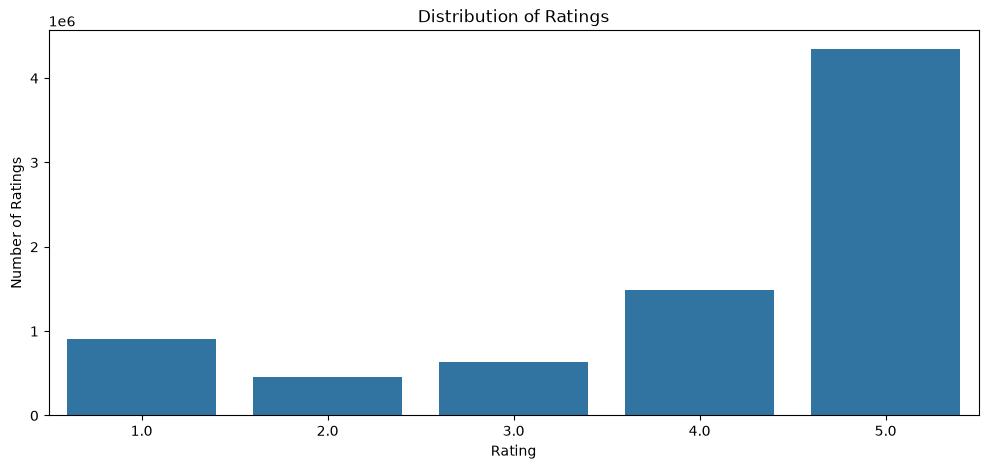

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

sns.countplot(x="Rating", data=df)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")

plt.show()

Most Active Users

In [14]:
top_users = (
    df.groupby("User_id")["Rating"]
      .count()
      .sort_values(ascending=False)
      .head(10)
)

print(top_users)

User_id
A5JLAU2ARJ0BO     520
ADLVFFE4VBT8      501
A3OXHLG6DIBRW8    498
A6FIAB28IS79      431
A680RUE1FDO8B     406
A1ODOGXEYECQQ8    380
A36K2N527TXXJN    314
A2AY4YUOX2N1BQ    311
AWPODHOB4GFWL     308
A25C2M3QF9G7OQ    296
Name: Rating, dtype: int64


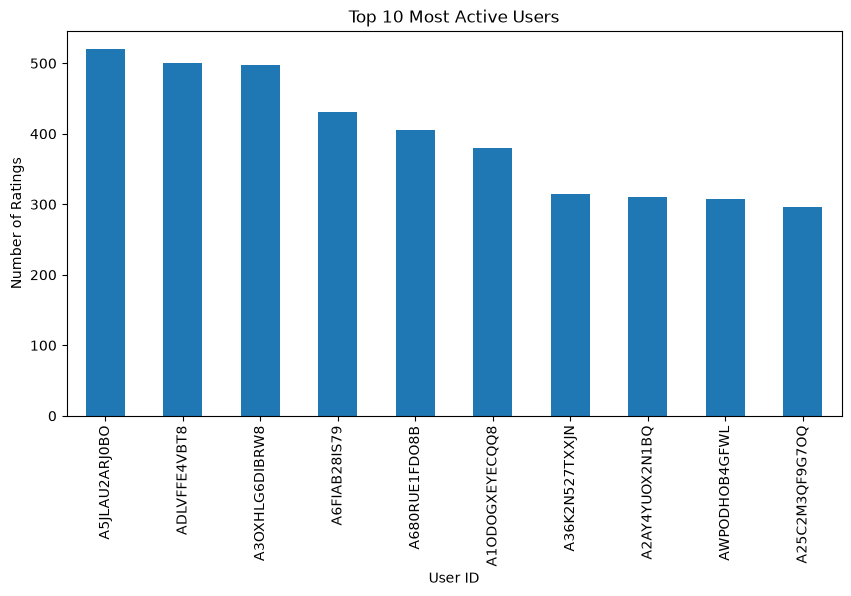

In [15]:
plt.figure(figsize=(10,5))

top_users.plot(kind="bar")

plt.title("Top 10 Most Active Users")
plt.xlabel("User ID")
plt.ylabel("Number of Ratings")

plt.show()

Most Popular Products

In [16]:
top_products=df.groupby("Product_id")["Rating"].count().sort_values(ascending=False).head(10)
print(top_products)

Product_id
B0074BW614    18244
B00DR0PDNE    16454
B007WTAJTO    14172
B0019EHU8G    12285
B006GWO5WK    12226
B003ELYQGG    11617
B003ES5ZUU    10276
B007R5YDYA     9907
B00622AG6S     9823
B0002L5R78     9487
Name: Rating, dtype: int64


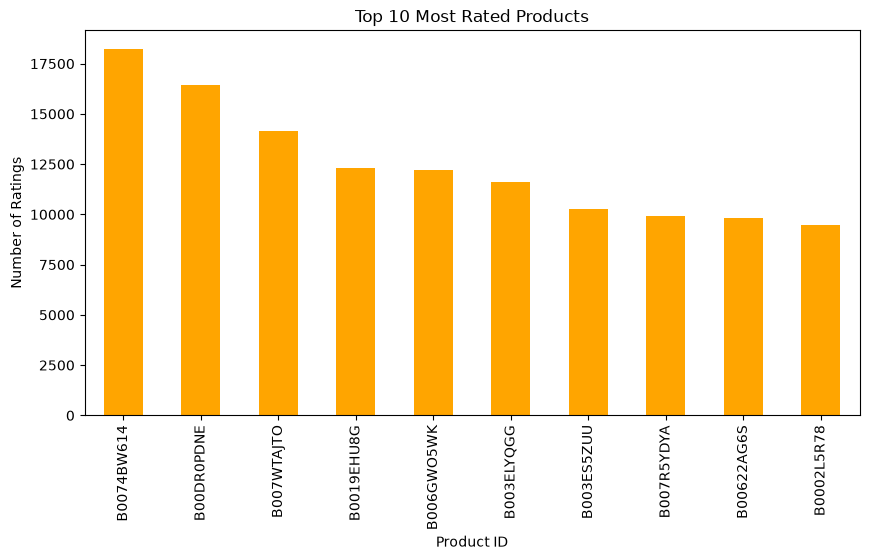

In [17]:
plt.figure(figsize=(10,5))

top_products.plot(kind="bar", color="orange")

plt.title("Top 10 Most Rated Products")
plt.xlabel("Product ID")
plt.ylabel("Number of Ratings")

plt.show()

In [18]:
average_rating = (
    df.groupby("Product_id")["Rating"]
      .mean()
      .sort_values(ascending=False)
)

average_rating.head(10)

Product_id
0132793040    5.0
B004SGH244    5.0
B004SQBRRM    5.0
B004SQC6O0    5.0
B004SQE6YI    5.0
B004SQFFCK    5.0
B004SQOR0G    5.0
B004SQVHU4    5.0
B004SQX8W4    5.0
B004SQYSUK    5.0
Name: Rating, dtype: float64

In [19]:
rating_count = (
    df.groupby("Product_id")["Rating"].count().sort_values(ascending=True)
)
rating_count.head()

Product_id
0132793040    1
B0058FM05U    1
B0058FM0M8    1
B0058FM320    1
B0058FM5IM    1
Name: Rating, dtype: int64

In [20]:
df.head()

,User_id,Product_id,Rating,Timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [21]:
product_stats = pd.DataFrame({
    "Average Rating": average_rating,
    "Rating Count": rating_count
})

product_stats.head()

,Average Rating,Rating Count
Product_id,,
0132793040,5.000000,1
0321732944,5.000000,1
0439886341,1.666667,3
0511189877,4.500000,6
0528881469,2.851852,27


Filter Popular Products

In [22]:
popular_products = product_stats[
    product_stats["Rating Count"] >= 30
]

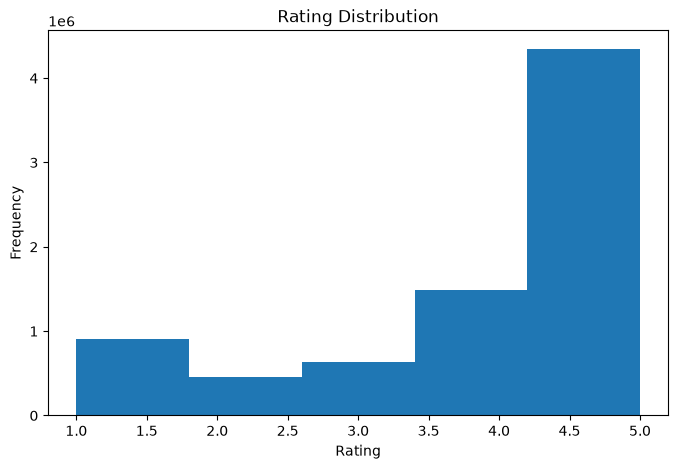

In [23]:
plt.figure(figsize=(8,5))

plt.hist(df["Rating"], bins=5)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

In [24]:
df["timestamp"] = pd.to_datetime(
    df["Timestamp"],
    unit="s"
)

df.head()

,User_id,Product_id,Rating,Timestamp,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200,2013-04-13
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800,2012-07-01
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600,2013-04-29
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200,2013-07-22
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200,2012-04-18


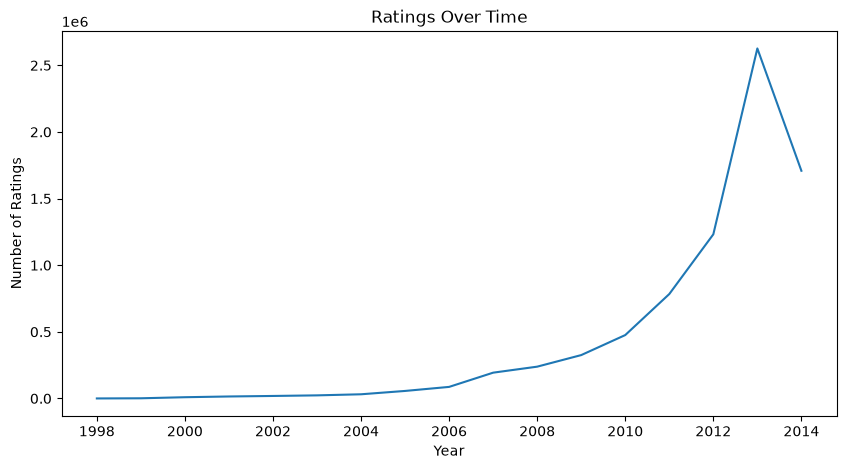

In [25]:
df["year"] = df["timestamp"].dt.year

ratings_per_year = (
    df.groupby("year")["Rating"]
      .count()
)

ratings_per_year.plot(figsize=(10,5))

plt.title("Ratings Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")

plt.show()

Filter Active Users

In [26]:
user_counts = df["User_id"].value_counts()

active_users = user_counts[user_counts >= 50].index

df_filtered = df[df["User_id"].isin(active_users)]
df_filtered.head()

,User_id,Product_id,Rating,Timestamp,timestamp,year
94,A3BY5KCNQZXV5U,0594451647,5.0,1390176000,2014-01-20,2014
118,AT09WGFUM934H,0594481813,3.0,1377907200,2013-08-31,2013
177,A32HSNCNPRUMTR,0970407998,1.0,1319673600,2011-10-27,2011
178,A17HMM1M7T9PJ1,0970407998,4.0,1281744000,2010-08-14,2010
492,A3CLWR1UUZT6TG,0972683275,5.0,1373587200,2013-07-12,2013


Filter Popular Products

In [27]:
product_counts = df_filtered["Product_id"].value_counts()

popular_products = product_counts[product_counts >= 50].index

df_filtered = df_filtered[df_filtered["Product_id"].isin(popular_products)]

In [28]:
df_filtered.shape

(6234, 6)

In [29]:
df_filtered.head()

,User_id,Product_id,Rating,Timestamp,timestamp,year
72043,A2YRX8J4WM5BRX,B00004ZCJE,5.0,1353715200,2012-11-24,2012
72059,AU627A4UGIW6V,B00004ZCJE,5.0,1369180800,2013-05-22,2013
72077,A16RL0RMRF974O,B00004ZCJE,5.0,1357776000,2013-01-10,2013
72121,AR8LWDT6TUKNZ,B00004ZCJE,5.0,1367971200,2013-05-08,2013
72122,AD9ZL63H0VKCZ,B00004ZCJE,5.0,1379376000,2013-09-17,2013


Create the User-Item Matrix

In [30]:
user_item_matrix = df_filtered.pivot_table(
    index="User_id",
    columns="Product_id",
    values="Rating"
)

In [31]:
user_item_matrix.shape

(1357, 77)

In [32]:
user_item_filled = user_item_matrix.fillna(0)

In [33]:
user_item_filled.to_csv("user_item_matrix.csv")

FILTER ACTIVE USERS

In [34]:
user_counts = df["User_id"].value_counts()

active_users = user_counts[user_counts >= 50].index

df_filtered_1 = df[df["User_id"].isin(active_users)]

FILTER POPULAR PRODUCTS

In [35]:
product_counts = df_filtered["Product_id"].value_counts()

popular_products = product_counts[product_counts >= 50].index

df_filtered = df_filtered[df_filtered["Product_id"].isin(popular_products)]

In [36]:
df_filtered.shape

(6234, 6)

In [37]:
df_filtered.head()

,User_id,Product_id,Rating,Timestamp,timestamp,year
72043,A2YRX8J4WM5BRX,B00004ZCJE,5.0,1353715200,2012-11-24,2012
72059,AU627A4UGIW6V,B00004ZCJE,5.0,1369180800,2013-05-22,2013
72077,A16RL0RMRF974O,B00004ZCJE,5.0,1357776000,2013-01-10,2013
72121,AR8LWDT6TUKNZ,B00004ZCJE,5.0,1367971200,2013-05-08,2013
72122,AD9ZL63H0VKCZ,B00004ZCJE,5.0,1379376000,2013-09-17,2013


USER ITEM MATRIX

In [38]:
user_item_matrix = df_filtered.pivot_table(
    index="User_id",
    columns="Product_id",
    values="Rating"
)

In [39]:
user_item_matrix = user_item_matrix.fillna(0)

In [40]:
user_item_matrix.to_csv("user_item_matrix.csv")

In [41]:
user_item_matrix.head()

Product_id,B00004ZCJE,B00007E7JU,B0002L5R78,B000BQ7GW8,B000HPV3RW,B000JE7GPY,B000JMJWV2,B000LRMS66,B000N99BBC,B000Q8UAWY,...,B009SYZ8OC,B00AQRUW4Q,B00ARB5FLQ,B00BGGDVOO,B00BOHNYTW,B00BOHNYU6,B00DR0PDNE,B00G4UQ6U8,B00HFRWWAM,B00JP12170
User_id,,,,,,,,,,,,,,,,,,,,,
A100UD67AHFODS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A100WO06OQR8BQ,0.0,0.0,1.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0
A105S56ODHGJEK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A105TOJ6LTVMBG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A10AFVU66A79Y1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Popularity-Based Recommendation System

In [42]:
average_rating = df_filtered.groupby("Product_id")["Rating"].mean()

average_rating.head()

Product_id
B00004ZCJE    4.250000
B00007E7JU    4.416667
B0002L5R78    4.611940
B000BQ7GW8    4.777778
B000HPV3RW    4.803922
Name: Rating, dtype: float64

Calculate Rating Count


In [43]:
rating_count = df_filtered.groupby("Product_id")["Rating"].count()

rating_count.head()

Product_id
B00004ZCJE    72
B00007E7JU    60
B0002L5R78    67
B000BQ7GW8    54
B000HPV3RW    51
Name: Rating, dtype: int64

In [44]:
product_stats = pd.DataFrame({
    "Average Rating": average_rating,
    "Rating Count": rating_count
})

product_stats.head()

,Average Rating,Rating Count
Product_id,,
B00004ZCJE,4.250000,72
B00007E7JU,4.416667,60
B0002L5R78,4.611940,67
B000BQ7GW8,4.777778,54
B000HPV3RW,4.803922,51


FILTER PRODUCTS WITH ENOUGH RATING

In [45]:
popular_products = product_stats[
    product_stats["Rating Count"] >= 50
]

SORT PRODUCTS

In [46]:
popular_products = popular_products.sort_values(
    by=["Average Rating", "Rating Count"],
    ascending=False
)

In [47]:
popular_products.head(10)

,Average Rating,Rating Count
Product_id,,
B001TH7GUU,4.871795,78
B003ES5ZUU,4.864130,184
B0019EHU8G,4.855556,90
B006W8U2MU,4.824561,57
B000QUUFRW,4.809524,84
B000HPV3RW,4.803922,51
B001TH7GSW,4.803279,61
B000BQ7GW8,4.777778,54
B000N99BBC,4.772455,167


In [48]:
def recommend_popular_products(n=10):
    return popular_products.head(n)

In [49]:
recommend_popular_products()

,Average Rating,Rating Count
Product_id,,
B001TH7GUU,4.871795,78
B003ES5ZUU,4.864130,184
B0019EHU8G,4.855556,90
B006W8U2MU,4.824561,57
B000QUUFRW,4.809524,84
B000HPV3RW,4.803922,51
B001TH7GSW,4.803279,61
B000BQ7GW8,4.777778,54
B000N99BBC,4.772455,167


User-Based Collaborative Filtering

In [50]:
from sklearn.metrics.pairwise import cosine_similarity

User similarity matrix

In [51]:
user_item_filled=user_item_matrix.fillna(0)

In [52]:
user_similarity = cosine_similarity(user_item_filled)

Convert to DataFrame

In [53]:
user_similarity_df=pd.DataFrame(
    user_similarity,
    index=user_item_filled.index,
    columns=user_item_filled.index
    
)

In [54]:
user_similarity_df.head(10)

User_id,A100UD67AHFODS,A100WO06OQR8BQ,A105S56ODHGJEK,A105TOJ6LTVMBG,A10AFVU66A79Y1,A10H24TDLK2VDP,A10NMELR4KX0J6,A10O7THJ2O20AG,A10PEXB6XAQ5XF,A10X9ME6R66JDX,...,AYOTEJ617O60K,AYP0YPLSP9ISM,AZ515FFZ7I2P7,AZ8XSDMIX04VJ,AZAC8O310IK4E,AZBXKUH4AIW3X,AZCE11PSTCH1L,AZMY6E8B52L2T,AZNUHQSHZHSUE,AZOK5STV85FBJ
User_id,,,,,,,,,,,,,,,,,,,,,
A100UD67AHFODS,1.000000,0.000000,0.000000,0.408248,0.000000,0.000000,0.372678,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.235702,0.437595,0.000000,0.0,0.408248,0.000000,0.000000
A100WO06OQR8BQ,0.000000,1.000000,0.112585,0.000000,0.105802,0.091538,0.227649,0.000000,0.000000,0.000000,...,0.0,0.033722,0.142501,0.000000,0.148502,0.203616,0.0,0.249377,0.000000,0.049875
A105S56ODHGJEK,0.000000,0.112585,1.000000,0.000000,0.199522,0.453134,0.000000,0.000000,0.304618,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.178458,0.000000
A105TOJ6LTVMBG,0.408248,0.000000,0.000000,1.000000,0.000000,0.000000,0.456435,0.000000,0.000000,0.000000,...,0.5,0.000000,0.000000,0.000000,0.297746,0.000000,0.0,0.500000,0.000000,0.000000
A10AFVU66A79Y1,0.000000,0.105802,0.199522,0.000000,1.000000,0.202777,0.000000,0.000000,0.000000,0.209657,...,0.0,0.000000,0.282843,0.163299,0.168430,0.000000,0.0,0.000000,0.000000,0.000000
A10H24TDLK2VDP,0.000000,0.091538,0.453134,0.000000,0.202777,1.000000,0.000000,0.000000,0.206392,0.000000,...,0.0,0.000000,0.000000,0.000000,0.136615,0.000000,0.0,0.000000,0.181369,0.000000
A10NMELR4KX0J6,0.372678,0.227649,0.000000,0.456435,0.000000,0.000000,1.000000,0.052705,0.000000,0.000000,...,0.0,0.000000,0.000000,0.052705,0.271803,0.000000,0.0,0.228218,0.000000,0.000000
A10O7THJ2O20AG,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.052705,1.000000,0.000000,0.599145,...,0.0,0.000000,0.000000,0.666667,0.000000,0.235702,0.0,0.000000,0.000000,0.000000
A10PEXB6XAQ5XF,0.000000,0.000000,0.304618,0.000000,0.000000,0.206392,0.000000,0.000000,1.000000,0.000000,...,0.0,0.000000,0.171360,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000


In [55]:
user_id = user_similarity_df.index[0]
print(user_id)

A100UD67AHFODS


Finding Similar Users

In [56]:
similar_users = user_similarity_df[user_id].sort_values(ascending=False)
similar_users.head(10)

User_id
A100UD67AHFODS    1.000000
A2VCXIAWCPQ13P    0.608164
A1ROUMJOGO4QMB    0.577350
A1435P5AMCPB3X    0.577350
A7EU2BWLLCJY2     0.577350
A7FDGFK0KN7QG     0.577350
AJL3U764D7NI3     0.577350
AK3GKIV8DEY8B     0.577350
A54SG05AV6S4H     0.577350
AWJWCKB92RJX2     0.577350
Name: A100UD67AHFODS, dtype: float64

Remove the User Themselves

In [57]:
similar_users = similar_users.drop(user_id)
similar_users.head(10)

User_id
A2VCXIAWCPQ13P    0.608164
A1ROUMJOGO4QMB    0.577350
A1435P5AMCPB3X    0.577350
A7EU2BWLLCJY2     0.577350
A7FDGFK0KN7QG     0.577350
AJL3U764D7NI3     0.577350
AK3GKIV8DEY8B     0.577350
A54SG05AV6S4H     0.577350
AWJWCKB92RJX2     0.577350
A324X7RVDAV3FT    0.577350
Name: A100UD67AHFODS, dtype: float64

Select the Top-K Similar Users

In [58]:
top_k_users=similar_users.head(5)
top_k_users

User_id
A2VCXIAWCPQ13P    0.608164
A1ROUMJOGO4QMB    0.577350
A1435P5AMCPB3X    0.577350
A7EU2BWLLCJY2     0.577350
A7FDGFK0KN7QG     0.577350
Name: A100UD67AHFODS, dtype: float64

In [59]:
top_k_user_ids = top_k_users.index
top_k_user_ids


Index(['A2VCXIAWCPQ13P', 'A1ROUMJOGO4QMB', 'A1435P5AMCPB3X', 'A7EU2BWLLCJY2',
       'A7FDGFK0KN7QG'],
      dtype='str', name='User_id')

In [60]:
len(top_k_users)

5

In [61]:
top_k_user_ids = top_k_users.index
len(top_k_user_ids)

5

Get Products Rated by Top-K Users

In [62]:
top_users_ratings = df_filtered[
    df_filtered["User_id"].isin(top_k_user_ids)
]

top_users_ratings.head()

,User_id,Product_id,Rating,Timestamp,timestamp,year
1091126,A2VCXIAWCPQ13P,B000JMJWV2,4.0,1369008000,2013-05-20,2013
1139957,A2VCXIAWCPQ13P,B000LRMS66,5.0,1369008000,2013-05-20,2013
1140946,A1ROUMJOGO4QMB,B000LRMS66,2.0,1266364800,2010-02-17,2010
1302279,A1435P5AMCPB3X,B000Q8UAWY,5.0,1231286400,2009-01-07,2009
1303430,A2VCXIAWCPQ13P,B000Q8UAWY,4.0,1368921600,2013-05-19,2013


Find Products Already Rated by the Target User

In [ ]:
user_products = df_filtered[
    df_filtered["User_id"] == user_id
]["Product_id"]

user_productss

1135848    B000LRMS66
1302488    B000Q8UAWY
6034310    B0082E9K7U
Name: Product_id, dtype: str

In [64]:
recommended_products = top_users_ratings[
    ~top_users_ratings["Product_id"].isin(user_products)
]
recommended_products.head()

,User_id,Product_id,Rating,Timestamp,timestamp,year
1091126,A2VCXIAWCPQ13P,B000JMJWV2,4.0,1369008000,2013-05-20,2013
3321463,A2VCXIAWCPQ13P,B003ES5ZUU,4.0,1369008000,2013-05-20,2013


In [65]:
final_recommendations = (
    recommended_products
    .groupby("Product_id")["Rating"]
    .mean()
    .sort_values(ascending=False)
)
final_recommendations.head(50)

Product_id
B000JMJWV2    4.0
B003ES5ZUU    4.0
Name: Rating, dtype: float64

In [66]:
def recommend_products(user_id, top_n=10):

    # Find similar users
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)
    # Remove the target user
    similar_users = similar_users.drop(user_id)

    # Select top 5 similar users
    top_k_users = similar_users.head(5)

    # Get their user IDs
    top_k_user_ids = top_k_users.index

    # Ratings given by similar users
    top_users_ratings = df_filtered[
        df_filtered["User_id"].isin(top_k_user_ids)
    ]

    # Products already rated by target user
    user_products = df_filtered[
        df_filtered["User_id"] == user_id
    ]["Product_id"]

    # Remove already rated products
    recommended_products = top_users_ratings[
        ~top_users_ratings["Product_id"].isin(user_products)
    ]

    # Rank products
    recommendations = (
        recommended_products
        .groupby("Product_id")["Rating"]
        .mean()
        .sort_values(ascending=False)
    )

    return recommendations.head(top_n)

In [67]:
recommend_products(user_id, top_n=5)

Product_id
B000JMJWV2    4.0
B003ES5ZUU    4.0
Name: Rating, dtype: float64

ITEM BASED COLLABORATIVE FILTERING

In [68]:
item_user_matrix = user_item_filled.T

In [69]:
item_user_matrix.head()

User_id,A100UD67AHFODS,A100WO06OQR8BQ,A105S56ODHGJEK,A105TOJ6LTVMBG,A10AFVU66A79Y1,A10H24TDLK2VDP,A10NMELR4KX0J6,A10O7THJ2O20AG,A10PEXB6XAQ5XF,A10X9ME6R66JDX,...,AYOTEJ617O60K,AYP0YPLSP9ISM,AZ515FFZ7I2P7,AZ8XSDMIX04VJ,AZAC8O310IK4E,AZBXKUH4AIW3X,AZCE11PSTCH1L,AZMY6E8B52L2T,AZNUHQSHZHSUE,AZOK5STV85FBJ
Product_id,,,,,,,,,,,,,,,,,,,,,
B00004ZCJE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B00007E7JU,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B0002L5R78,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
B000BQ7GW8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,0.0
B000HPV3RW,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0


In [70]:
item_similarity=cosine_similarity(item_user_matrix)

In [71]:
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_matrix.index,
    columns=item_user_matrix.index
)

In [72]:
item_similarity_df.head(10)

Product_id,B00004ZCJE,B00007E7JU,B0002L5R78,B000BQ7GW8,B000HPV3RW,B000JE7GPY,B000JMJWV2,B000LRMS66,B000N99BBC,B000Q8UAWY,...,B009SYZ8OC,B00AQRUW4Q,B00ARB5FLQ,B00BGGDVOO,B00BOHNYTW,B00BOHNYU6,B00DR0PDNE,B00G4UQ6U8,B00HFRWWAM,B00JP12170
Product_id,,,,,,,,,,,,,,,,,,,,,
B00004ZCJE,1.000000,0.172307,0.074258,0.076122,0.058678,0.050206,0.086933,0.069937,0.050481,0.037150,...,0.056484,0.040029,0.075426,0.055447,0.024740,0.061721,0.059135,0.034146,0.045240,0.047248
B00007E7JU,0.172307,1.000000,0.073713,0.040049,0.041162,0.046119,0.018899,0.022077,0.030222,0.028503,...,0.040901,0.019145,0.028935,0.055008,0.050619,0.049086,0.094890,0.019961,0.113833,0.043866
B0002L5R78,0.074258,0.073713,1.000000,0.048359,0.125764,0.085912,0.150757,0.072030,0.079588,0.059598,...,0.061384,0.024519,0.039326,0.116652,0.062842,0.055956,0.046959,0.062083,0.070053,0.067771
B000BQ7GW8,0.076122,0.040049,0.048359,1.000000,0.061373,0.037508,0.090173,0.087778,0.045517,0.060713,...,0.028586,0.064704,0.016435,0.062135,0.097037,0.082571,0.066489,0.115080,0.048004,0.024224
B000HPV3RW,0.058678,0.041162,0.125764,0.061373,1.000000,0.047117,0.085728,0.045860,0.070172,0.095679,...,0.056149,0.035207,0.077703,0.089407,0.096779,0.034718,0.030195,0.049758,0.014096,0.039836
B000JE7GPY,0.050206,0.046119,0.085912,0.037508,0.047117,1.000000,0.110135,0.093426,0.035738,0.021187,...,0.068499,0.058175,0.040434,0.054641,0.045150,0.038506,0.024282,0.037389,0.088305,0.024346
B000JMJWV2,0.086933,0.018899,0.150757,0.090173,0.085728,0.110135,1.000000,0.115294,0.051551,0.118422,...,0.056957,0.045262,0.058945,0.058644,0.067841,0.043216,0.050349,0.089887,0.068607,0.051213
B000LRMS66,0.069937,0.022077,0.072030,0.087778,0.045860,0.093426,0.115294,1.000000,0.041400,0.064704,...,0.040854,0.076930,0.033975,0.034252,0.029717,0.079999,0.025571,0.058333,0.013861,0.036499
B000N99BBC,0.050481,0.030222,0.079588,0.045517,0.070172,0.035738,0.051551,0.041400,1.000000,0.016197,...,0.098417,0.178425,0.194965,0.026049,0.136016,0.127024,0.075138,0.077587,0.178773,0.114113


Item Similarity Matrix

In [73]:
product_id = item_similarity_df.index[0]
print(product_id)

B00004ZCJE


In [74]:
similar_products = item_similarity_df[product_id].sort_values(ascending=False)
similar_products.head(10)

Product_id
B00004ZCJE    1.000000
B00007E7JU    0.172307
B000QUUFRW    0.141192
B007WTAJTO    0.130291
B006W8U2MU    0.112146
B002WE6D44    0.098683
B005HMKKH4    0.096235
B001E1Y5O6    0.094458
B000VX6XL6    0.088860
B000JMJWV2    0.086933
Name: B00004ZCJE, dtype: float64

In [75]:
similar_products = similar_products.drop(product_id)
similar_products.head(10)

Product_id
B00007E7JU    0.172307
B000QUUFRW    0.141192
B007WTAJTO    0.130291
B006W8U2MU    0.112146
B002WE6D44    0.098683
B005HMKKH4    0.096235
B001E1Y5O6    0.094458
B000VX6XL6    0.088860
B000JMJWV2    0.086933
B002SQK2F2    0.085860
Name: B00004ZCJE, dtype: float64

In [76]:
def recommend_similar_products(product_id, top_n=10):

    similar_products = item_similarity_df[product_id].sort_values(
        ascending=False
    )

    similar_products = similar_products.drop(product_id)

    return similar_products.head(top_n)

In [77]:
recommend_similar_products(product_id)

Product_id
B00007E7JU    0.172307
B000QUUFRW    0.141192
B007WTAJTO    0.130291
B006W8U2MU    0.112146
B002WE6D44    0.098683
B005HMKKH4    0.096235
B001E1Y5O6    0.094458
B000VX6XL6    0.088860
B000JMJWV2    0.086933
B002SQK2F2    0.085860
Name: B00004ZCJE, dtype: float64

In [78]:
item_similarity_df.shape

(77, 77)

In [79]:
item_user_matrix.shape

(77, 1357)

SVD

In [80]:
from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise.accuracy import rmse

In [81]:
reader = Reader(rating_scale=(1, 5))

In [82]:
data = Dataset.load_from_df(
    df[["User_id", "Product_id", "Rating"]],
    reader
)

In [83]:
df.shape

(7824482, 6)

In [84]:
trainset, testset =train_test_split(data,test_size=0.2,random_state=42)




In [85]:
model = SVD()

model.fit(trainset)

In [86]:
User_id = df_filtered["User_id"].iloc[0]
Product_id = df_filtered["Product_id"].iloc[0]

prediction = model.predict(user_id, product_id)

print(prediction.est)

4.165607695367117


In [87]:
def recommend_svd(User_id, top_n=10):

    products = df_filtered["Product_id"].unique()

    predictions = []

    for product in products:
        pred = model.predict(User_id, product)
        predictions.append((product, pred.est))

    predictions.sort(key=lambda x: x[1], reverse=True)

    return predictions[:top_n]

In [88]:
recommend_svd(User_id)

[('B00004ZCJE', 5),
 ('B00007E7JU', 5),
 ('B000BQ7GW8', 5),
 ('B000JE7GPY', 5),
 ('B000JMJWV2', 5),
 ('B000LRMS66', 5),
 ('B000N99BBC', 5),
 ('B000QUUFRW', 5),
 ('B000VX6XL6', 5),
 ('B0019EHU8G', 5)]

In [89]:
df.columns

Index(['User_id', 'Product_id', 'Rating', 'Timestamp', 'timestamp', 'year'], dtype='str')

In [90]:
user_id

'A100UD67AHFODS'

In [91]:
user_similarity_df.index[:5]

Index(['A100UD67AHFODS', 'A100WO06OQR8BQ', 'A105S56ODHGJEK', 'A105TOJ6LTVMBG',
       'A10AFVU66A79Y1'],
      dtype='str', name='User_id')

In [92]:
recommend_products

<function __main__.recommend_products(user_id, top_n=10)>

In [93]:
User_cf = recommend_products(User_id, top_n=10)
Item_cf = recommend_similar_products(Product_id)

svd_cf = recommend_svd(User_id)

Hybrid Recommendation Systems

In [94]:
recommend_products(User_id)

Series([], Name: Rating, dtype: float64)

In [95]:
recommend_similar_products(Product_id)

Product_id
B00007E7JU    0.172307
B000QUUFRW    0.141192
B007WTAJTO    0.130291
B006W8U2MU    0.112146
B002WE6D44    0.098683
B005HMKKH4    0.096235
B001E1Y5O6    0.094458
B000VX6XL6    0.088860
B000JMJWV2    0.086933
B002SQK2F2    0.085860
Name: B00004ZCJE, dtype: float64

In [96]:
def recommend_svd(user_id, top_n=10):

    products = df_filtered["Product_id"].unique()

    predictions = []

    for product in products:
        pred = model.predict(user_id, product)
        predictions.append((product, pred.est))

    predictions.sort(key=lambda x: x[1], reverse=True)

    return predictions[:top_n]

In [97]:
user_cf = recommend_products(User_id, top_n=10)

item_cf = recommend_similar_products(Product_id)

svd_cf = recommend_svd(User_id)

In [98]:
hybrid_products = set()

hybrid_products.update(user_cf.index)

hybrid_products.update(item_cf.index)

hybrid_products.update([x[0] for x in svd_cf])

print(hybrid_products)

{'B001E1Y5O6', 'B005HMKKH4', 'B002SQK2F2', 'B000LRMS66', 'B007WTAJTO', 'B000VX6XL6', 'B002WE6D44', 'B000JMJWV2', 'B000JE7GPY', 'B0019EHU8G', 'B000BQ7GW8', 'B00004ZCJE', 'B000N99BBC', 'B006W8U2MU', 'B000QUUFRW', 'B00007E7JU'}
